# 02 — Data Cleaning & Preprocessing

Notebook ini bertugas (mengacu pada SLR):
1. Membersihkan dataset dari file corrupt / non-image
2. Menyiapkan dataset bersih untuk training (opsional resize + segmentasi)
3. Menganalisis distribusi kelas setelah pembersihan
4. Menghitung class weights untuk menangani class imbalance (balance)
5. Menyimpan metadata preprocessing ke JSON

**Jalankan SEBELUM notebook training (03 dan 04).**

Ringkasan teknik SLR yang diterapkan:
- Standarisasi ukuran (Resizing) ✅
- Augmentasi data (Rotasi, Flip, Zooming) ✅ (on-the-fly saat training)
- Normalisasi piksel ✅ (pada pipeline training)
- Segmentasi citra (Background Removal) ✅ (opsional, bisa diaktifkan)
- Ekstraksi fitur otomatis (CNN) ✅ (dilakukan di model)
- Ekstraksi fitur manual ✅ (opsional, tidak dipakai pada training utama)

### [CELL 1] — Import Libraries & Definisi Path

Cell ini memuat modul bawaan *Python* untuk manipulasi file sistem (os, shutil, glob) dan struktur path.
<br><sub>**Kenapa butuh ini?** Kita perlu mencari, memverifikasi, dan bahkan memindahkan gambar yang rusak langsung dari *File System* Windows kita, tanpa menyajikan gambar tersebut ke model dulu. Tanpa tools ini, pembersihan level disk tidak bisa jalan.</sub>

In [8]:
import os
import sys
import json
import glob
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Konfigurasi plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_palette('husl')

# Path setup
BASE_DIR = Path.cwd().parent  # backend/
DATASET_DIR = BASE_DIR / "dataset" / "Indian Medicinal Leaves Image Datasets"
LEAF_DATASET_DIR = DATASET_DIR / "Medicinal Leaf dataset"     # 80 kelas
REPORTS_PREP_DIR = BASE_DIR / "reports" / "preprocessing"
REPORTS_PREP_DIR.mkdir(parents=True, exist_ok=True)

# Folder karantina untuk file corrupt
QUARANTINE_DIR = BASE_DIR / "dataset" / "_quarantine"
QUARANTINE_DIR.mkdir(parents=True, exist_ok=True)

# Output dataset bersih (nama asli dataset)
CLEAN_DATASET_DIR = BASE_DIR / "dataset" / "dataset_bersih"

print("✅ Libraries imported successfully")
print(f"📂 Base directory: {BASE_DIR}")
print(f"📂 Leaf dataset: {LEAF_DATASET_DIR} (exists: {LEAF_DATASET_DIR.exists()})")
print(f"📂 Quarantine dir: {QUARANTINE_DIR}")
print(f"📂 Clean dataset dir: {CLEAN_DATASET_DIR}")

# Konfigurasi preprocessing (SLR)
RESIZE_OUTPUT = True
TARGET_SIZE = (224, 224)
APPLY_SEGMENTATION = False  # Background removal sederhana (opsional)

✅ Libraries imported successfully
📂 Base directory: d:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend
📂 Leaf dataset: d:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\dataset\Indian Medicinal Leaves Image Datasets\Medicinal Leaf dataset (exists: True)
📂 Quarantine dir: d:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\dataset\_quarantine
📂 Clean dataset dir: d:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\dataset\dataset_bersih


### [CELL 2] — Melakukan Sweeping (Sapu Bersih) Mendalam

Membuka satu-persatu file di dalam dataset Leaf untuk dicek apakah struktur *byte*-nya dapat dibaca sebagai format gambar (JPEG/PNG) menggunakan library PIL.Image.open().
<br><sub>**Kenapa harus repot cek byte-nya?** Karena Windows Explorer mungkin menampilkan foto yang seakan-akan ada ukurannya (misal 15 KB), namun file itu *corrupt* secara *hex header*. Model AI akan langsung *crash* saat training bila ada gambar rusak.</sub>
<br><sub>**Penjelasan Output:** Proses ini menghasilkan list mana gambar yang 100% sehat (*valid*), dan mana yang rusak (*corrupt*).</sub>

In [9]:
def scan_all_files(dataset_path, dataset_name="Dataset"):
    """
    Scan semua file di dalam dataset dan kategorikan:
    - valid_images: file gambar yang bisa dibuka oleh PIL
    - corrupt_files: file yang TIDAK bisa dibuka oleh PIL (corrupt / bukan gambar)
    """
    valid_images = []
    corrupt_files = []
    
    classes = sorted([d for d in os.listdir(dataset_path) 
                      if os.path.isdir(os.path.join(dataset_path, d))])
    
    print(f"\n{'='*60}")
    print(f"🔍 Scanning: {dataset_name}")
    print(f"   Path: {dataset_path}")
    print(f"   Jumlah kelas ditemukan: {len(classes)}")
    print(f"{'='*60}")
    
    for class_name in classes:
        class_dir = os.path.join(dataset_path, class_name)
        all_files = glob.glob(os.path.join(class_dir, "*.*"))
        
        for file_path in all_files:
            file_ext = os.path.splitext(file_path)[1].lower()
            file_size = os.path.getsize(file_path)
            
            try:
                with Image.open(file_path) as img:
                    img.verify()  # Verifikasi integritas file gambar
                # Buka ulang untuk mendapatkan info (verify() menutup file)
                with Image.open(file_path) as img:
                    width, height = img.size
                    img_format = img.format
                    img_mode = img.mode
                    
                valid_images.append({
                    'class_name': class_name,
                    'file_path': file_path,
                    'file_name': os.path.basename(file_path),
                    'extension': file_ext,
                    'file_size': file_size,
                    'width': width,
                    'height': height,
                    'format': img_format,
                    'mode': img_mode,
                    'dataset': dataset_name
                })
            except Exception as e:
                corrupt_files.append({
                    'class_name': class_name,
                    'file_path': file_path,
                    'file_name': os.path.basename(file_path),
                    'extension': file_ext,
                    'file_size': file_size,
                    'error': str(e),
                    'dataset': dataset_name
                })
    
    print(f"\n📊 Hasil scan {dataset_name}:")
    print(f"   ✅ Gambar valid: {len(valid_images)}")
    print(f"   ❌ File corrupt/non-image: {len(corrupt_files)}")
    
    return valid_images, corrupt_files

# Scan dataset Leaf saja
valid_leaf, corrupt_leaf = scan_all_files(LEAF_DATASET_DIR, "Medicinal Leaf (80 kelas)")

# Gabungkan hasil
all_valid = valid_leaf
all_corrupt = corrupt_leaf

print(f"\n{'='*60}")
print(f"📊 TOTAL KESELURUHAN")
print(f"   ✅ Gambar valid: {len(all_valid)}")
print(f"   ❌ File corrupt: {len(all_corrupt)}")
print(f"{'='*60}")



🔍 Scanning: Medicinal Leaf (80 kelas)
   Path: d:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\dataset\Indian Medicinal Leaves Image Datasets\Medicinal Leaf dataset
   Jumlah kelas ditemukan: 80

📊 Hasil scan Medicinal Leaf (80 kelas):
   ✅ Gambar valid: 6900
   ❌ File corrupt/non-image: 0

📊 TOTAL KESELURUHAN
   ✅ Gambar valid: 6900
   ❌ File corrupt: 0

📊 Hasil scan Medicinal Leaf (80 kelas):
   ✅ Gambar valid: 6900
   ❌ File corrupt/non-image: 0

📊 TOTAL KESELURUHAN
   ✅ Gambar valid: 6900
   ❌ File corrupt: 0


### [CELL 3] — Investigasi & Detail File Bermasalah

Menampilkan path detail mana saja tepatnya file yang dicap '*corrupt*' tadi.
<br><sub>**Kenapa harus di-print out?** Agar pengguna tahu ini bukan *system error*, melainkan murni error dari gambar tersebut yang gagal di-*load* memori. Bukti transparansi untuk validasi manual.</sub>

In [10]:
if all_corrupt:
    print(f"\n🚨 DETAIL FILE CORRUPT ({len(all_corrupt)} file):")
    print(f"{'─'*80}")
    
    df_corrupt = pd.DataFrame(all_corrupt)
    
    # Tampilkan setiap file corrupt
    for i, row in df_corrupt.iterrows():
        print(f"   {i+1}. [{row['dataset']}] {row['class_name']}/{row['file_name']}")
        print(f"      Extension: {row['extension']} | Size: {row['file_size']/1024:.1f} KB")
        print(f"      Error: {row['error']}")
        print()
    
    # Ringkasan per extension
    print(f"📊 Breakdown per extension:")
    ext_counts = df_corrupt['extension'].value_counts()
    for ext, count in ext_counts.items():
        print(f"   {ext}: {count} file")
    
    # Ringkasan per dataset
    print(f"\n📊 Breakdown per dataset:")
    ds_counts = df_corrupt['dataset'].value_counts()
    for ds, count in ds_counts.items():
        print(f"   {ds}: {count} file corrupt")
else:
    print("\n✅ Tidak ada file corrupt ditemukan! Dataset sudah bersih.")


✅ Tidak ada file corrupt ditemukan! Dataset sudah bersih.


### [CELL 4] — Pindahkan File Corrupt ke Folder Karantina

Menghukum gambar-gambar yang rusak dari atas, lalu memindahkannya secara fisik dari folder kelas (/dataset) ke folder pembuangan sementara (/_quarantine).
<br><sub>**Kenapa dipindah?** Supaya bersih! Kenapa tidak didelete permanen? Sebagai *best practice*, seorang data engineer tidak boleh menghapus data bawaan sembarangan tanpa jejak (*Safe Deletion*). Jadi kita simpan sementara di Karantina.</sub>
<br><sub>**Penjelasan Output:** Ada konfirmasi sukses dipindah. Kalau di-*Run* dua kali, errornya nol karena sudah bersih dari run pertama.</sub>

In [11]:
if all_corrupt:
    print(f"\n🔄 Memindahkan {len(all_corrupt)} file corrupt ke folder karantina...")
    print(f"   Tujuan: {QUARANTINE_DIR}")
    
    moved_count = 0
    for item in all_corrupt:
        src_path = item['file_path']
        # Buat subfolder berdasarkan dataset dan kelas
        rel_folder = f"{item['dataset'].replace(' ', '_')}/{item['class_name']}"
        dst_dir = QUARANTINE_DIR / rel_folder
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst_path = dst_dir / item['file_name']
        
        try:
            shutil.move(str(src_path), str(dst_path))
            moved_count += 1
            print(f"   ✅ Moved: {item['class_name']}/{item['file_name']}")
        except Exception as e:
            print(f"   ⚠️  Gagal memindahkan {item['file_name']}: {e}")
    
    print(f"\n✅ Selesai! {moved_count}/{len(all_corrupt)} file dipindahkan ke karantina.")
    print(f"   File TIDAK dihapus permanen — masih bisa di-restore dari {QUARANTINE_DIR}")
else:
    print("\n✅ Tidak ada file yang perlu dipindahkan.")


✅ Tidak ada file yang perlu dipindahkan.


### [CELL 5] — Menghitung Total Populasi Kelas (Pasca-Pembersihan)

Menghitung jumlah gambar valid per kelas setelah cleaning dan menyiapkan **dataset bersih** untuk training.
<br><sub>**Penjelasan Output:** Menampilkan ringkasan distribusi per kelas, membuat folder `dataset_bersih`, serta menyiapkan data yang lebih *bersih* dan *balanced* (melalui class weights).</sub>

In [12]:
# Safety checks agar cell ini bisa jalan dengan jelas
required = ['scan_all_files', 'LEAF_DATASET_DIR', 'CLEAN_DATASET_DIR']
missing = [r for r in required if r not in globals()]
if missing:
    raise RuntimeError(f"Jalankan CELL 1–2 dulu. Missing: {missing}")

if not LEAF_DATASET_DIR.exists():
    raise RuntimeError(f"Dataset tidak ditemukan: {LEAF_DATASET_DIR}")

# Re-scan setelah pembersihan untuk mendapatkan distribusi terbaru
valid_leaf_clean, _ = scan_all_files(LEAF_DATASET_DIR, "Medicinal Leaf (cleaned)")

df_valid = pd.DataFrame(valid_leaf_clean)

# Distribusi per kelas (nama asli)
class_counts = df_valid['class_name'].value_counts().sort_values(ascending=True)

print(f"\n📊 Distribusi Kelas (setelah cleaning):")
print(f"   Total kelas unik: {len(class_counts)}")
print(f"   Total gambar: {len(df_valid)}")
print(f"   Min gambar/kelas: {class_counts.min()} ({class_counts.idxmin()})")
print(f"   Max gambar/kelas: {class_counts.max()} ({class_counts.idxmax()})")
print(f"   Rata-rata: {class_counts.mean():.1f}")
print(f"   Std deviasi: {class_counts.std():.1f}")
print(f"   Median: {class_counts.median():.1f}")

# Imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\n⚖️  Imbalance Ratio (max/min): {imbalance_ratio:.2f}x")
if imbalance_ratio > 5:
    print(f"   🚨 Dataset SANGAT IMBALANCED! Perlu penanganan khusus.")
elif imbalance_ratio > 2:
    print(f"   ⚠️  Dataset CUKUP IMBALANCED. Disarankan pakai class weights.")
else:
    print(f"   ✅ Dataset relatif BALANCED.")

# -------------------------------
# Segmentasi sederhana (background removal)
# Lebih soft agar daun tidak hilang
# -------------------------------
def simple_segment_leaf(pil_img):
    # Konversi ke HSV dan ambil rentang hijau + area ber-saturasi tinggi
    hsv = np.array(pil_img.convert('HSV'))
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    mask_green = (h >= 25) & (h <= 100) & (s >= 25)
    mask_sat = (s >= 60) & (v >= 40)
    mask = mask_green | mask_sat
    
    # Dilation ringan (mempertebal area daun agar tidak terpotong)
    mask = mask.astype(np.uint8)
    padded = np.pad(mask, 1, mode='edge')
    dilated = (
        padded[0:-2, 0:-2] | padded[0:-2, 1:-1] | padded[0:-2, 2:] |
        padded[1:-1, 0:-2] | padded[1:-1, 1:-1] | padded[1:-1, 2:] |
        padded[2:, 0:-2] | padded[2:, 1:-1] | padded[2:, 2:]
    )
    rgb = np.array(pil_img)
    rgb[~dilated.astype(bool)] = [255, 255, 255]
    return Image.fromarray(rgb)

# -------------------------------
# Buat dataset bersih untuk training
# -------------------------------
if CLEAN_DATASET_DIR.exists():
    shutil.rmtree(CLEAN_DATASET_DIR)
CLEAN_DATASET_DIR.mkdir(parents=True, exist_ok=True)

copied = 0
for item in valid_leaf_clean:
    class_name = item['class_name']
    src_path = Path(item['file_path'])
    dst_dir = CLEAN_DATASET_DIR / class_name
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst_path = dst_dir / src_path.name
    if dst_path.exists():
        continue
    try:
        img = Image.open(src_path).convert('RGB')
        if APPLY_SEGMENTATION:
            img = simple_segment_leaf(img)
        if RESIZE_OUTPUT:
            img = img.resize(TARGET_SIZE)
        img.save(dst_path)
        copied += 1
    except Exception as e:
        print(f"⚠️  Gagal proses {src_path.name}: {e}")

print(f"\n✅ Dataset bersih dibuat di: {CLEAN_DATASET_DIR}")
print(f"   Total gambar disalin: {copied}")


🔍 Scanning: Medicinal Leaf (cleaned)
   Path: d:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\dataset\Indian Medicinal Leaves Image Datasets\Medicinal Leaf dataset
   Jumlah kelas ditemukan: 80

📊 Hasil scan Medicinal Leaf (cleaned):
   ✅ Gambar valid: 6900
   ❌ File corrupt/non-image: 0

📊 Distribusi Kelas (setelah cleaning):
   Total kelas unik: 80
   Total gambar: 6900
   Min gambar/kelas: 8 (Lemongrass)
   Max gambar/kelas: 177 (Tulsi)
   Rata-rata: 86.2
   Std deviasi: 33.3
   Median: 79.5

⚖️  Imbalance Ratio (max/min): 22.12x
   🚨 Dataset SANGAT IMBALANCED! Perlu penanganan khusus.

📊 Hasil scan Medicinal Leaf (cleaned):
   ✅ Gambar valid: 6900
   ❌ File corrupt/non-image: 0

📊 Distribusi Kelas (setelah cleaning):
   Total kelas unik: 80
   Total gambar: 6900
   Min gambar/kelas: 8 (Lemongrass)
   Max gambar/kelas: 177 (Tulsi)
   Rata-rata: 86.2
   Std deviasi: 33.3
   Median: 79.5

⚖️  Imbalance Ratio (max/min): 22.12x
   🚨 Dataset SANGAT IMBALA

### [CELL 6] — Visualisasi Distribusi Kelas (Bersih)

Mencetak grafik *Bar Chart* dari dataset Leaf setelah cleaning.
<br><sub>**Kenapa dianalisis ulang?** Karena kita ingin melihat ketimpangan kelas pada dataset bersih yang akan dipakai training. Semakin panjang ekor grafiknya, semakin besar gap antar kelas.</sub>
<br><sub>**Penjelasan Output:** Jika rentangnya jauh, class weights perlu digunakan pada training.</sub>

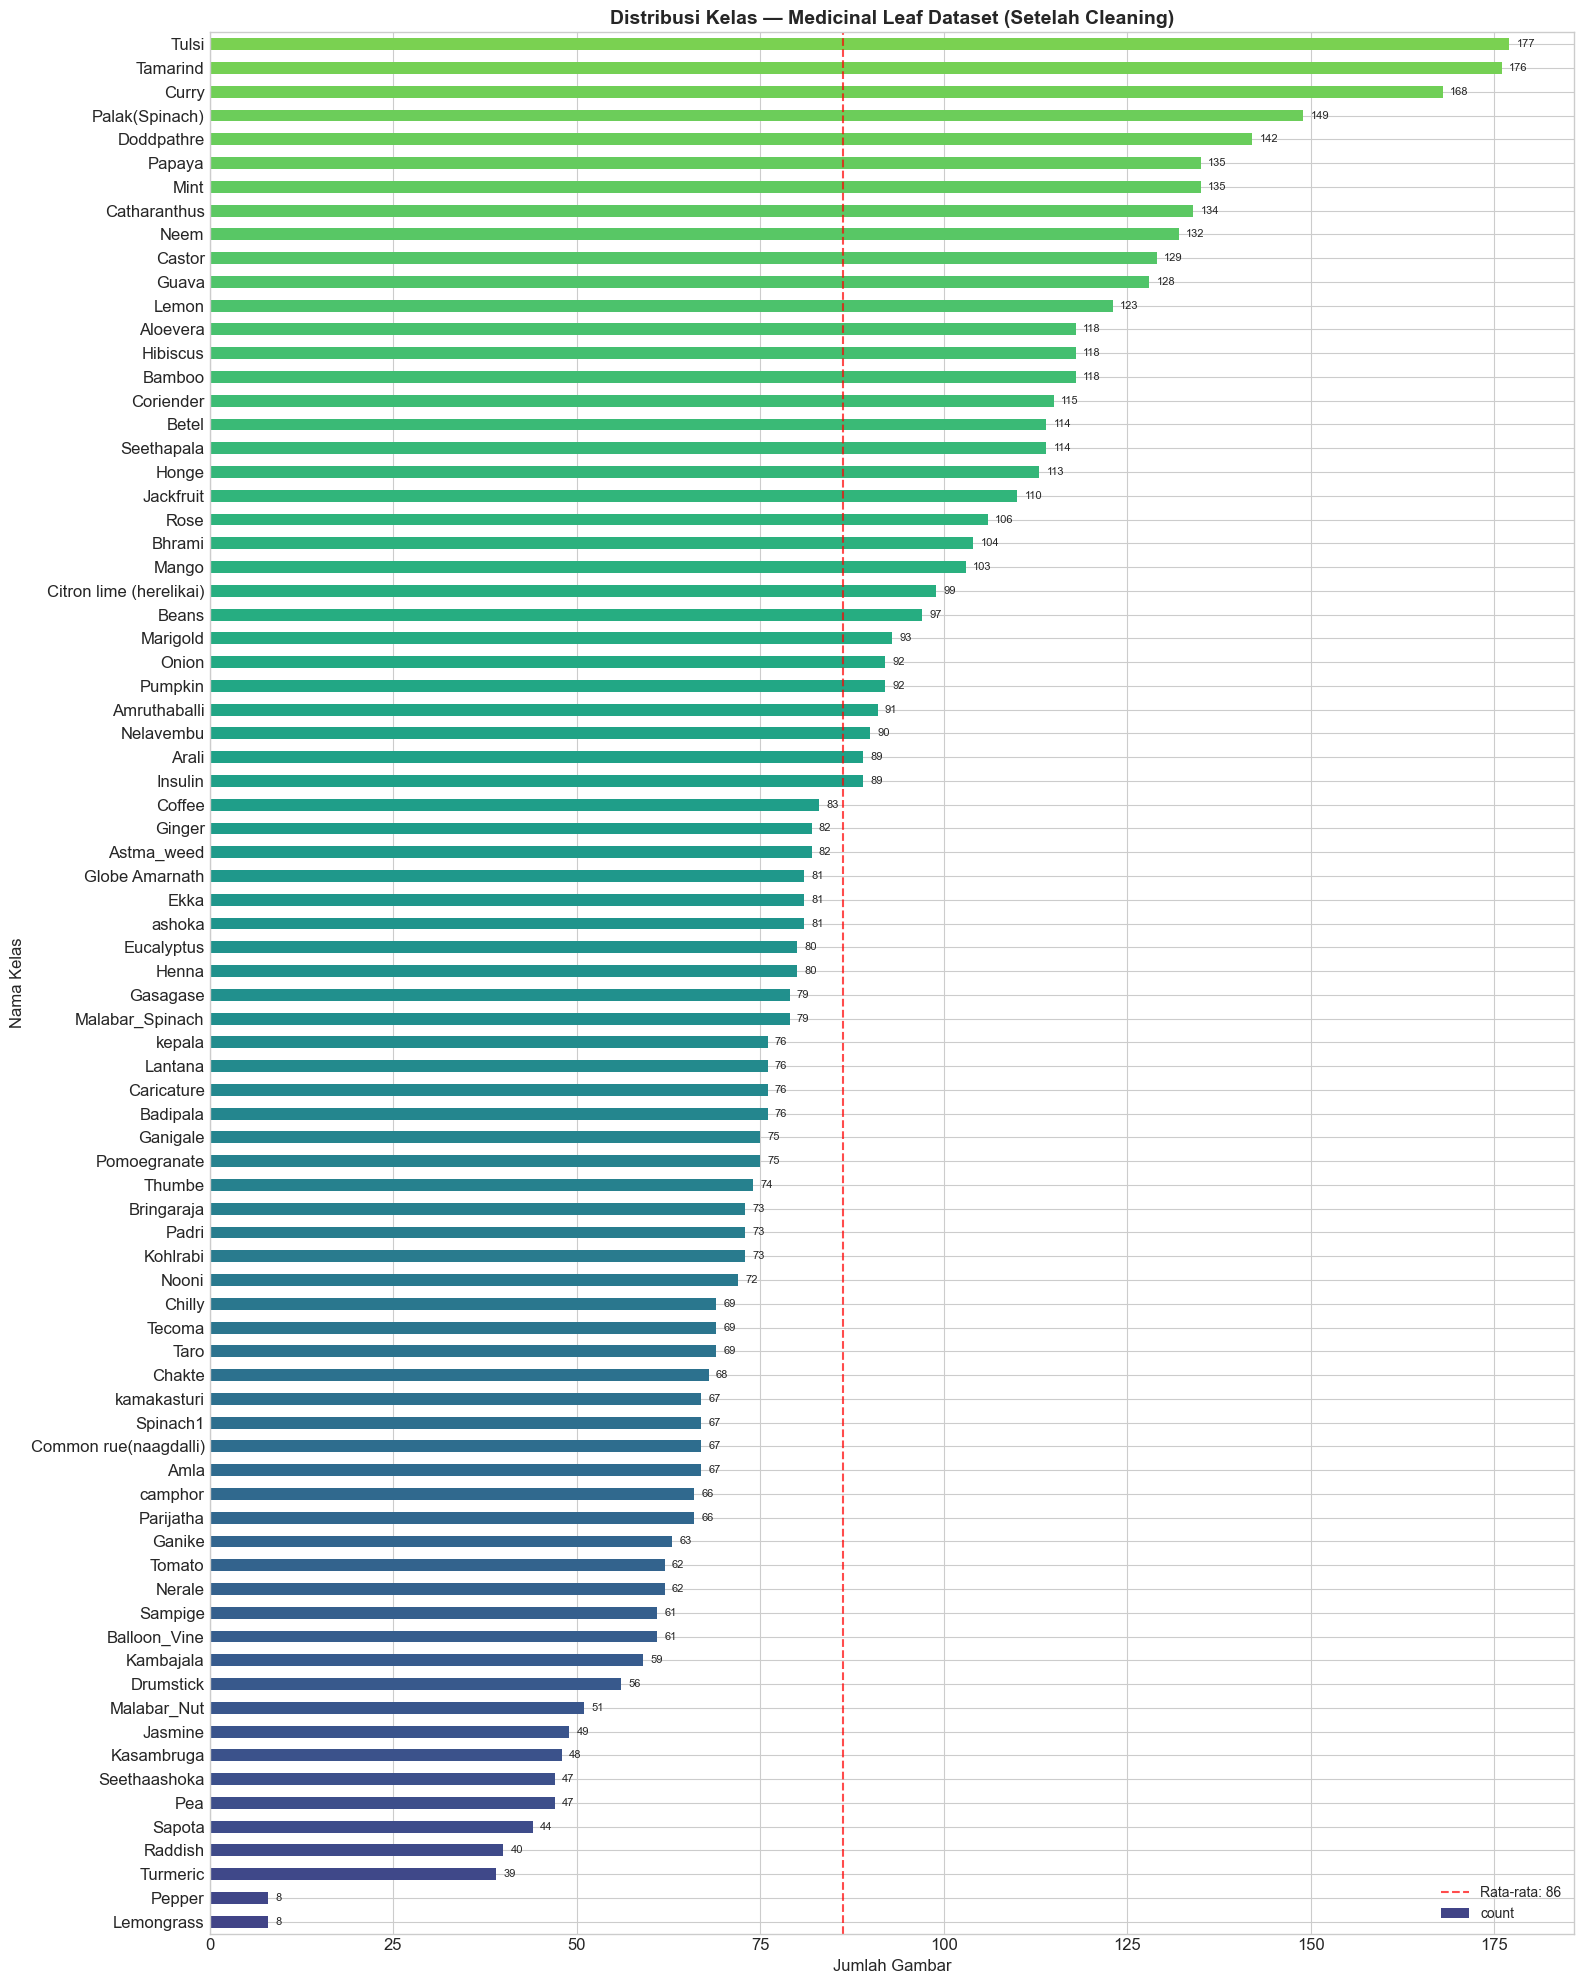

💾 Grafik disimpan ke: reports/preprocessing/preprocessing_distribusi_bersih.png


In [13]:
fig, ax = plt.subplots(1, 1, figsize=(16, max(10, len(class_counts) * 0.25)))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(class_counts)))
class_counts.plot(kind='barh', ax=ax, color=colors)

ax.set_title('Distribusi Kelas — Medicinal Leaf Dataset (Setelah Cleaning)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Gambar')
ax.set_ylabel('Nama Kelas')

# Angka di ujung bar
for i, (v, name) in enumerate(zip(class_counts.values, class_counts.index)):
    ax.text(v + 1, i, str(v), va='center', fontsize=8)

# Garis rata-rata
ax.axvline(x=class_counts.mean(), color='red', linestyle='--', alpha=0.7, 
           label=f'Rata-rata: {class_counts.mean():.0f}')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(str(REPORTS_PREP_DIR / 'preprocessing_distribusi_bersih.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Grafik disimpan ke: reports/preprocessing/preprocessing_distribusi_bersih.png")

### [CELL 7] — Kalkulasi Hukuman Bias (Matematika Class Weights)

Menghitung skor kompensasi bobot menggunakan perbandingan matematika terbalik.
<br><sub>**Definisi Inti (Apa itu Imbalance?):** Data yang tidak imbang bikin model pilih kasih belajar anak emas (daun gambar banyak). 
<br>**Terus solusinya? -> *Class Weights***. Matematika di baliknya: Kelas minoritas diberikan nilai 'skor ujian' (Bobot / *Weight*) lebih tinggi dari kelas mayoritas. 
<br>*- Ibaratnya:* Salah menebak daun mayoritas, model dipukul 1 kali. Namun jika salah menebak daun minoritas, model dipukul **36 kali**. Dengan begini, model akan dipaksa memperhatikan daun yang miskin gambar!</sub>
<br><sub>**Penjelasan Output:** Memberikan koefisien pengali bobot (multiplier) yang secara akurat menyeimbangkan skala rasio ketimpangan yang mencapai misal 36.12x lipat.</sub>

In [14]:
# Class weights memberikan "bobot lebih" pada kelas yang sedikit gambarnya,
# sehingga model tidak bias ke kelas yang banyak datanya.
#
# Formula: weight_i = total_samples / (num_classes * count_i)
# Kelas dengan sedikit data → weight BESAR → model lebih "perhatian"
# Kelas dengan banyak data → weight KECIL → model tidak over-learn

sorted_classes = sorted(df_valid['class_name'].unique())
num_classes = len(sorted_classes)
total_samples = len(df_valid)

class_weights = {}
class_weight_list = []

print(f"\n⚖️  PERHITUNGAN CLASS WEIGHTS")
print(f"{'─'*60}")
print(f"{'Kelas':<30} {'Jumlah':>8} {'Weight':>10}")
print(f"{'─'*60}")

for cls in sorted_classes:
    count = len(df_valid[df_valid['class_name'] == cls])
    weight = total_samples / (num_classes * count)
    class_weights[cls] = round(weight, 4)
    class_weight_list.append(weight)
    print(f"{cls:<30} {count:>8} {weight:>10.4f}")

print(f"{'─'*60}")
print(f"{'TOTAL':<30} {total_samples:>8}")
print(f"\n📝 Kelas dengan weight tertinggi (paling sedikit data):")
top_weights = sorted(class_weights.items(), key=lambda x: x[1], reverse=True)[:5]
for cls, w in top_weights:
    print(f"   {cls}: {w:.4f}")

print(f"\n📝 Kelas dengan weight terendah (paling banyak data):")
bottom_weights = sorted(class_weights.items(), key=lambda x: x[1])[:5]
for cls, w in bottom_weights:
    print(f"   {cls}: {w:.4f}")


⚖️  PERHITUNGAN CLASS WEIGHTS
────────────────────────────────────────────────────────────
Kelas                            Jumlah     Weight
────────────────────────────────────────────────────────────
Aloevera                            118     0.7309
Amla                                 67     1.2873
Amruthaballi                         91     0.9478
Arali                                89     0.9691
Astma_weed                           82     1.0518
Badipala                             76     1.1349
Balloon_Vine                         61     1.4139
Bamboo                              118     0.7309
Beans                                97     0.8892
Betel                               114     0.7566
Bhrami                              104     0.8293
Bringaraja                           73     1.1815
Caricature                           76     1.1349
Castor                              129     0.6686
Catharanthus                        134     0.6437
Chakte                         

### [CELL 8] — Ekspor Formula Preprocessing (ke format JSON)

Menyimpan variabel Class Weights, list nama kelas rapi, dan jumlah spesimen ke dalam dompet metadata_preprocessing.json offline.
<br><sub>**Kenapa disimpan di JSON?** Parameter PyTorch di Notebook berikutnya (Notebook 03/04) **wajib** mengetahui hasil kompensasi bobot (*class_weights*) kita agar loss function (CrossEntropyLoss) bisa distel menggunakan *Weights* ini. Daripada menghitung ulang dari nol, lebih baik simpan di JSON, lalu suruh model tinggal *Load/Baca*. Sangat efisien!</sub>

In [15]:
metadata = {
    "timestamp": pd.Timestamp.now().isoformat(),
    "datasets_used": [
        {
            "name": "Medicinal Leaf dataset",
            "path": str(LEAF_DATASET_DIR),
            "num_classes": len(set(item['class_name'] for item in valid_leaf_clean)),
            "num_images": len(valid_leaf_clean)
        }
    ],
    "cleaning_summary": {
        "total_corrupt_files_found": len(all_corrupt),
        "total_files_quarantined": moved_count if all_corrupt else 0,
        "quarantine_dir": str(QUARANTINE_DIR),
        "corrupt_file_details": [
            {"file": item['file_name'], "class": item['class_name'], 
             "dataset": item['dataset'], "error": item['error']}
            for item in all_corrupt
        ]
    },
    "dataset_after_cleaning": {
        "total_classes": num_classes,
        "total_images": total_samples,
        "min_images_per_class": int(class_counts.min()),
        "max_images_per_class": int(class_counts.max()),
        "mean_images_per_class": round(float(class_counts.mean()), 2),
        "imbalance_ratio": round(float(imbalance_ratio), 2),
        "class_distribution": {cls: int(class_counts.get(cls, 0)) for cls in sorted_classes}
    },
    "clean_dataset": {
        "name": "dataset_bersih",
        "path": str(CLEAN_DATASET_DIR),
        "total_classes": num_classes,
        "total_images": int(total_samples),
        "resize_output": RESIZE_OUTPUT,
        "target_size": list(TARGET_SIZE),
        "segmentation_enabled": APPLY_SEGMENTATION
    },
    "class_weights": class_weights,
    "class_weight_tensor_order": sorted_classes,
    "preprocessing_config": {
        "image_size": 224,
        "train_ratio": 0.80,
        "test_ratio": 0.20,
        "normalization": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225]
        },
        "augmentation": [
            "RandomHorizontalFlip(p=0.5)",
            "RandomVerticalFlip(p=0.3)",
            "RandomRotation(15)",
            "ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)",
            "RandomAffine(scale=(0.85, 1.15))",
            "GaussianBlur(kernel_size=3)"
        ]
    }
}

metadata_path = REPORTS_PREP_DIR / "preprocessing_metadata.json"
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"\n💾 Metadata preprocessing disimpan ke:")
print(f"   {metadata_path}")
print(f"   Ukuran file: {os.path.getsize(metadata_path) / 1024:.1f} KB")


💾 Metadata preprocessing disimpan ke:
   d:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\reports\preprocessing\preprocessing_metadata.json
   Ukuran file: 6.9 KB


### [CELL 9] — Verifikasi Tahap Akhir (Checkpoint)

Menutup sub-sesi *Preprocessing* dengan menyajikan Ringkasan Akhir Data.
<br><sub>**Maksud Output:** Ini lampu hijau yang memberi aba-aba bahwa Dataset A dan Dataset B sudah *Corrupt-Free*, Kelas-kelasnya tersusun mateng beserta Class Weights, dan Data Engineer telah *Ready* untuk melempar wajan mateng ini ke dalam Model Deep Learning!</sub>

In [16]:
# Re-scan terakhir untuk memastikan tidak ada file corrupt tersisa
_, remaining_corrupt_leaf = scan_all_files(LEAF_DATASET_DIR, "Leaf (final check)")
remaining_total = len(remaining_corrupt_leaf)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║            📋 RINGKASAN PREPROCESSING                        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. File Corrupt                                             ║
║     - Ditemukan: {len(all_corrupt):>4} file                              ║
║     - Dipindahkan ke karantina: {moved_count if all_corrupt else 0:>4} file                  ║
║     - Sisa file corrupt: {remaining_total:>4} file                       ║
║                                                              ║
║  2. Dataset Setelah Cleaning                                 ║
║     - Total kelas unik: {num_classes:>4}                                ║
║     - Total gambar valid: {total_samples:>6}                            ║
║     - Min gambar/kelas: {int(class_counts.min()):>5}                              ║
║     - Max gambar/kelas: {int(class_counts.max()):>5}                              ║
║     - Imbalance ratio: {imbalance_ratio:>6.2f}x                            ║
║                                                              ║
║  3. Class Weights (Balance)                                  ║
║     - Dihitung dan disimpan ke JSON ✅                       ║
║     - Digunakan untuk menyeimbangkan kelas saat training     ║
║                                                              ║
║  4. Output Files                                             ║
║     - reports/preprocessing/preprocessing_metadata.json                    ║
║     - reports/preprocessing/preprocessing_distribusi_bersih.png            ║
║     - dataset/dataset_bersih/ (nama asli dataset)                         ║
║                                                              ║
║  Next Step: → 03_training_mobilenetv2.ipynb                  ║
╚══════════════════════════════════════════════════════════════╝
""")

if remaining_total > 0:
    print("⚠️  PERHATIAN: Masih ada file corrupt tersisa! Periksa kembali.")
else:
    print("✅ Dataset BERSIH dan SIAP untuk training!")
    print("   Lanjutkan ke notebook 03_training_mobilenetv2.ipynb")


🔍 Scanning: Leaf (final check)
   Path: d:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\dataset\Indian Medicinal Leaves Image Datasets\Medicinal Leaf dataset
   Jumlah kelas ditemukan: 80

📊 Hasil scan Leaf (final check):
   ✅ Gambar valid: 6900
   ❌ File corrupt/non-image: 0

╔══════════════════════════════════════════════════════════════╗
║            📋 RINGKASAN PREPROCESSING                        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. File Corrupt                                             ║
║     - Ditemukan:    0 file                              ║
║     - Dipindahkan ke karantina:    0 file                  ║
║     - Sisa file corrupt:    0 file                       ║
║                                                              ║
║  2. Dataset Setelah Cleaning                                 ║
║     - Total kelas unik:   80                     